In [2]:
# Kurduğumuz kütüphaneleri çağırıyoruz
import pandas as pd
import numpy as np

# İndirdiğimiz Excel dosyasını okuyup 'df' (dataframe) adında bir değişkene atıyoruz
# Eğer klasöründeki dosyanın adı farklıysa, tırnak içindeki ismi ona göre düzeltmelisin.
df = pd.read_excel('churn_data.xlsx')

# Verinin ilk 5 satırını ekrana yazdıralım ki doğru okuduğumuzdan emin olalım
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
# 'Total Charges' sütununu zorla sayıya (numeric) dönüştürüyoruz.
# errors='coerce' parametresi: "Eğer sayıya çeviremediğin boşluklar (' ') bulursan hata verme,
# onları matematiksel bir boşluk olan NaN (Eksik Veri) değerine çevir" demektir.
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Acaba kaç tane hücre boşluk olduğu için NaN'a dönüştü? Bunu saydıralım:
print("Total Charges sütunundaki eksik veri sayısı:", df['Total Charges'].isnull().sum())

Total Charges sütunundaki eksik veri sayısı: 11


In [6]:
# 1. Verimizi hatalı halinden kurtarıp, Excel'den tertemiz yeniden okuyoruz
df = pd.read_excel('churn_data.xlsx')

# 2. 'Total Charges' sütunundaki boşlukları önce NaN yapıyoruz
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 3. PROFESYONEL DOKUNUŞ: NaN olan (yeni gelen) müşterilerin toplam faturasına 0 yazıyoruz
df['Total Charges'] = df['Total Charges'].fillna(0)

# 4. PROFESYONEL DOKUNUŞ: Churn Reason (Ayrılma Sebebi) boş olanlara "Ayrılmadı" yazıyoruz
df['Churn Reason'] = df['Churn Reason'].fillna('Ayrılmadı')

# Kontrol edelim bakalım hiç eksik verimiz kalmış mı? (Hepsinin 0 çıkması lazım)
print("Verisetindeki eksik veri (NaN) sayıları:")
print(df[['Total Charges', 'Churn Reason']].isnull().sum())

Verisetindeki eksik veri (NaN) sayıları:
Total Charges    0
Churn Reason     0
dtype: int64


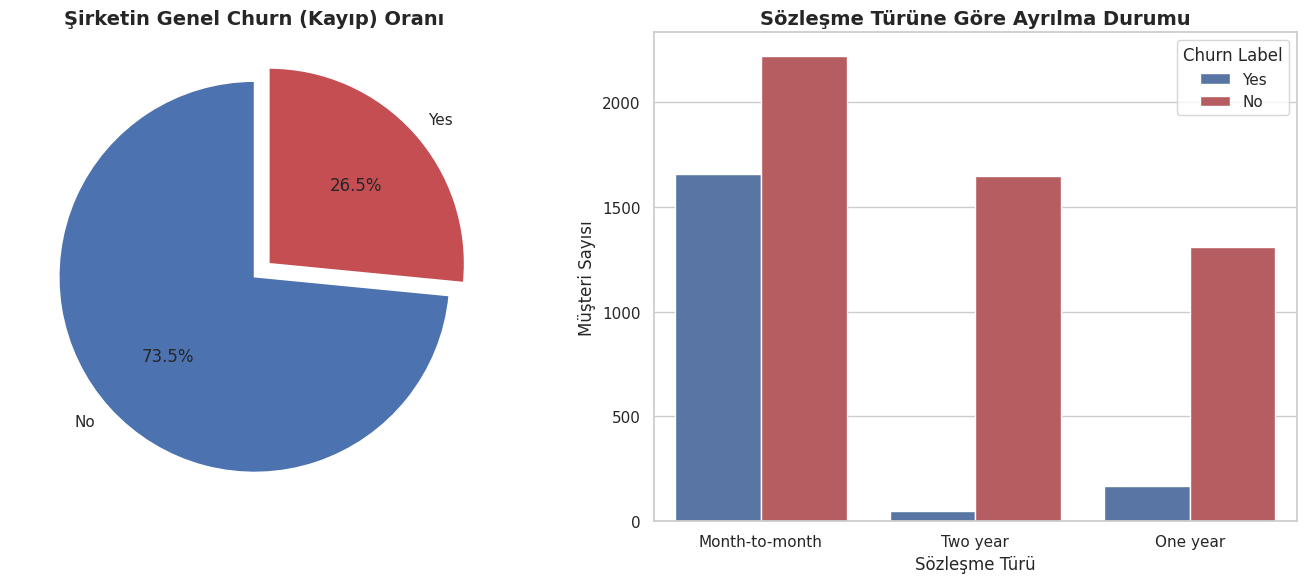

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin daha şık ve profesyonel görünmesi için bir tema seçiyoruz
sns.set_theme(style="whitegrid")

# Yan yana iki grafik çizeceğimiz geniş bir tuval oluşturuyoruz
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. GRAFİK: Genel Churn Oranı (Pasta Grafiği)
churn_counts = df['Churn Label'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#C44E52'], explode=(0, 0.1))
axes[0].set_title('Şirketin Genel Churn (Kayıp) Oranı', fontsize=14, fontweight='bold')

# 2. GRAFİK: Sözleşme Türüne (Contract) Göre Churn Dağılımı (Sütun Grafiği)
sns.countplot(data=df, x='Contract', hue='Churn Label', ax=axes[1], palette=['#4C72B0', '#C44E52'])
axes[1].set_title('Sözleşme Türüne Göre Ayrılma Durumu', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sözleşme Türü', fontsize=12)
axes[1].set_ylabel('Müşteri Sayısı', fontsize=12)

# Ekrana temiz bir şekilde basıyoruz
plt.tight_layout()
plt.show()